In [1]:
!pip install -q pandas tqdm requests evaluate sentence-transformers scikit-learn rouge-score sacrebleu

In [2]:
import pandas as pd
import requests
import time
from tqdm import tqdm
import evaluate
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
OLLAMA_URL = " https://armandina-shingly-ruminatingly.ngrok-free.dev"   # change this

models = [
    ("llama3.2", "llama3.2:3b"),
    ("gemma3", "gemma3:270m")
]

OPTIMIZER_MODEL = "llama3:latest"

In [4]:
def ollama_generate(model, prompt, max_tokens=120):
    try:
        time.sleep(1.5)

        response = requests.post(
            f"{OLLAMA_URL}/api/generate",
            json={
                "model": model,
                "prompt": prompt,
                "stream": False,
                "options": {
                    "num_predict": max_tokens,
                    "temperature": 0.0
                }
            },
            timeout=120
        )

        return response.json()["response"]

    except:
        return "ERROR"


def safe_generate(model, prompt):
    for _ in range(3):
        result = ollama_generate(model, prompt)
        if result != "ERROR":
            return result
        time.sleep(2)
    return "ERROR"

In [5]:
df = pd.read_csv("/content/50_prompts.csv")   # your dataset
df = df.reset_index(drop=True)

print(df.head())

   prompt_type                                             prompt  \
0        basic                           Explain machine learning   
1   structured  Provide a structured explanation of machine le...   
2      concise                   Explain machine learning briefly   
3  role_prompt        You are an expert. Explain machine learning   
4     few_shot  Example: Q: What is AI? A: AI is intelligence ...   

                                           reference  
0  Machine learning is a method where systems lea...  
1  Machine learning is a method where systems lea...  
2  Machine learning is a method where systems lea...  
3  Machine learning is a method where systems lea...  
4  Machine learning is a method where systems lea...  


In [6]:
pip install -q bert-score

In [7]:
bertscore = evaluate.load("bertscore")
rouge = evaluate.load("rouge")
embed_model = SentenceTransformer("all-MiniLM-L6-v2")


def evaluate_df(df):

    # BERTScore
    berts = bertscore.compute(
        predictions=df["response"].tolist(),
        references=df["reference"].tolist(),
        lang="en"
    )
    df["bertscore"] = berts["f1"]

    # ROUGE
    df["rougeL"] = [
        rouge.compute(predictions=[p], references=[r])["rougeL"]
        for p, r in zip(df["response"], df["reference"])
    ]

    # Embedding similarity
    emb1 = embed_model.encode(df["response"].tolist(), convert_to_numpy=True)
    emb2 = embed_model.encode(df["reference"].tolist(), convert_to_numpy=True)

    df["embedding_score"] = [
        cosine_similarity([e1], [e2])[0][0]
        for e1, e2 in zip(emb1, emb2)
    ]

    # Final score
    df["final_score"] = (
        0.4 * df["bertscore"] +
        0.3 * df["embedding_score"] +
        0.3 * df["rougeL"]
    )

    return df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
results = []

for model_name, model_id in models:
    print(f"\nRunning ORIGINAL: {model_name}\n")

    for _, row in tqdm(df.iterrows(), total=len(df)):

        response = safe_generate(model_id, row["prompt"])

        results.append({
            "prompt": row["prompt"],
            "prompt_type": row["prompt_type"],
            "model": model_name,
            "response": response,
            "reference": row["reference"]
        })

results_df = pd.DataFrame(results)
results_df = results_df[results_df["response"] != "ERROR"].reset_index(drop=True)


Running ORIGINAL: llama3.2



100%|██████████| 50/50 [03:54<00:00,  4.69s/it]



Running ORIGINAL: gemma3



100%|██████████| 50/50 [02:20<00:00,  2.82s/it]


In [9]:
results_df = evaluate_df(results_df)

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
def optimize_prompt_llm(prompt, prompt_type):

    meta_prompt = f"""
You are an expert prompt engineer.

Rewrite the prompt to maximize similarity with the reference answer.

STRICT INSTRUCTIONS:
- Keep answers concise (very important)
- Avoid unnecessary explanation
- Match expected answer style
- Do NOT make answers longer
- Focus on accuracy and relevance

Adapt based on prompt type: {prompt_type}

Return ONLY the improved prompt.

Original Prompt:
{prompt}
"""

    improved = safe_generate(OPTIMIZER_MODEL, meta_prompt)

    if improved == "ERROR" or len(improved.strip()) < 5:
        return prompt

    return improved.strip()

In [19]:
optimized_results = []

for model_name, model_id in models:
    print(f"\nRunning OPTIMIZED: {model_name}\n")

    for _, row in tqdm(df.iterrows(), total=len(df)):

        optimized_prompt = optimize_prompt_llm(
            row["prompt"],
            row["prompt_type"]
        )

        response = safe_generate(model_id, optimized_prompt)

        optimized_results.append({
            "original_prompt": row["prompt"],
            "optimized_prompt": optimized_prompt,
            "prompt_type": row["prompt_type"],
            "model": model_name,
            "response": response,
            "reference": row["reference"]
        })

optimized_df = pd.DataFrame(optimized_results)
optimized_df = optimized_df[optimized_df["response"] != "ERROR"].reset_index(drop=True)


Optimizing prompts using llama3...



100%|██████████| 50/50 [04:36<00:00,  5.53s/it]


In [13]:
optimized_results = []

for model_name, model_id in models:

    print(f"\nRunning OPTIMIZED: {model_name}\n")

    for _, row in tqdm(df.iterrows(), total=len(df)):

        response = safe_generate(
            model_id,
            row["optimized_prompt"]   # ✅ no optimizer call here
        )

        optimized_results.append({
            "original_prompt": row["prompt"],
            "optimized_prompt": row["optimized_prompt"],
            "prompt_type": row["prompt_type"],
            "model": model_name,
            "response": response,
            "reference": row["reference"]
        })

optimized_df = pd.DataFrame(optimized_results)
optimized_df = optimized_df[optimized_df["response"] != "ERROR"].reset_index(drop=True)


Running OPTIMIZED: llama3.2



100%|██████████| 50/50 [04:24<00:00,  5.29s/it]



Running OPTIMIZED: gemma3



100%|██████████| 50/50 [02:11<00:00,  2.63s/it]


In [14]:
optimized_df = evaluate_df(optimized_df)

In [15]:
before_scores = results_df.groupby("model")["final_score"].mean()
after_scores = optimized_df.groupby("model")["final_score"].mean()

comparison = pd.DataFrame({
    "Original": before_scores,
    "Optimized": after_scores
})

comparison["Improvement"] = (
    comparison["Optimized"] - comparison["Original"]
)

print("\nFINAL COMPARISON:\n")
print(comparison)


FINAL COMPARISON:

          Original  Optimized  Improvement
model                                     
gemma3    0.569776   0.488663    -0.081113
llama3.2  0.598149   0.574396    -0.023753


In [16]:
import matplotlib.pyplot as plt

<Figure size 640x480 with 0 Axes>

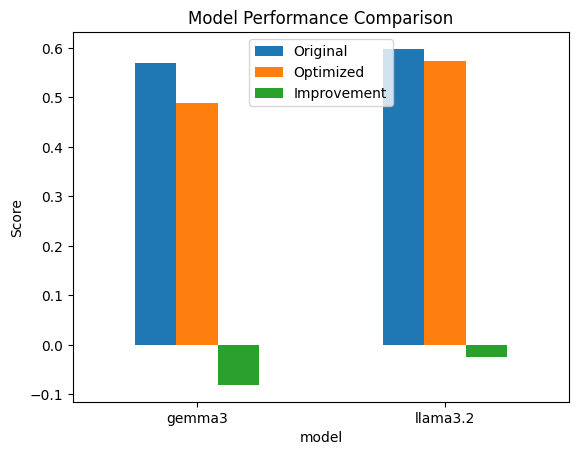

In [17]:
plt.figure()
comparison.plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [21]:
def optimize_prompt_for_score(prompt, prompt_type):

    meta_prompt = f"""
You are an expert in prompt optimization for evaluation metrics.

Rewrite the prompt to maximize:
- semantic similarity with reference answers
- concise responses (VERY IMPORTANT)
- direct answers

STRICT RULES:
- Keep answers short (1-2 sentences)
- Avoid explanations unless necessary
- Use precise wording
- Match likely reference style

Prompt type: {prompt_type}

Return ONLY improved prompt.

Original Prompt:
{prompt}
"""

    improved = safe_generate(OPTIMIZER_MODEL, meta_prompt)

    if improved == "ERROR" or len(improved.strip()) < 5:
        return prompt

    return improved.strip()

In [22]:
score_prompts = []

print("\nGenerating SCORE-OPTIMIZED prompts...\n")

for _, row in tqdm(df.iterrows(), total=len(df)):

    sp = optimize_prompt_for_score(
        row["prompt"],
        row["prompt_type"]
    )

    # 🔥 extra constraint (VERY IMPORTANT)
    sp += "\n\nAnswer concisely in 1-2 sentences."

    score_prompts.append(sp)

df["score_prompt"] = score_prompts


Generating SCORE-OPTIMIZED prompts...



100%|██████████| 50/50 [14:06<00:00, 16.92s/it]


In [23]:
score_results = []

for model_name, model_id in models:

    print(f"\nRunning SCORE-OPTIMIZED: {model_name}\n")

    for _, row in tqdm(df.iterrows(), total=len(df)):

        response = safe_generate(
            model_id,
            row["score_prompt"]
        )

        score_results.append({
            "original_prompt": row["prompt"],
            "score_prompt": row["score_prompt"],
            "prompt_type": row["prompt_type"],
            "model": model_name,
            "response": response,
            "reference": row["reference"]
        })

score_df = pd.DataFrame(score_results)
score_df = score_df[score_df["response"] != "ERROR"].reset_index(drop=True)


Running SCORE-OPTIMIZED: llama3.2



100%|██████████| 50/50 [03:17<00:00,  3.95s/it]



Running SCORE-OPTIMIZED: gemma3



100%|██████████| 50/50 [02:07<00:00,  2.55s/it]


In [24]:
score_df = evaluate_df(score_df)

In [25]:
before_scores = results_df.groupby("model")["final_score"].mean()
after_scores = optimized_df.groupby("model")["final_score"].mean()
score_scores = score_df.groupby("model")["final_score"].mean()

comparison = pd.DataFrame({
    "Original": before_scores,
    "Optimized": after_scores,
    "Score_Optimized": score_scores
})

comparison["Best"] = comparison.max(axis=1)

print("\nFINAL 3-WAY COMPARISON:\n")
print(comparison)


FINAL 3-WAY COMPARISON:

          Original  Optimized  Score_Optimized      Best
model                                                   
gemma3    0.569776   0.488663         0.609469  0.609469
llama3.2  0.598149   0.574396         0.631059  0.631059


<Figure size 640x480 with 0 Axes>

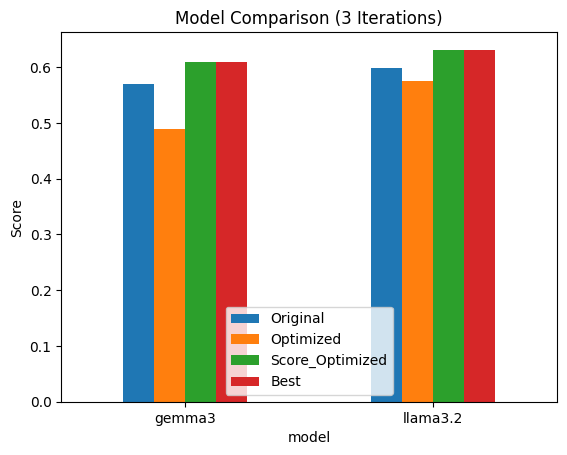

In [27]:
import matplotlib.pyplot as plt

plt.figure()
comparison.plot(kind="bar")

plt.title("Model Comparison (3 Iterations)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

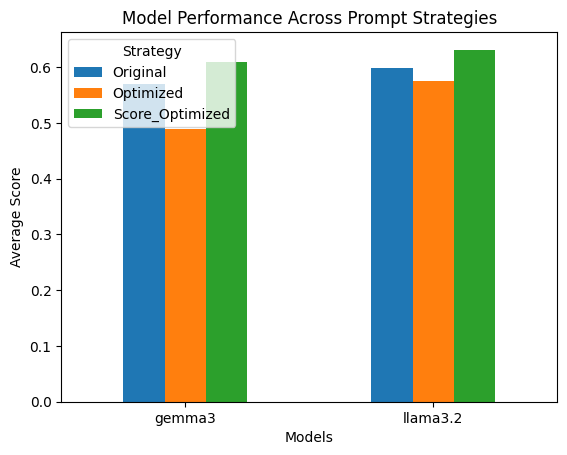

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Compute scores
before_scores = results_df.groupby("model")["final_score"].mean()
after_scores = optimized_df.groupby("model")["final_score"].mean()
score_scores = score_df.groupby("model")["final_score"].mean()

# Combine
comparison = pd.DataFrame({
    "Original": before_scores,
    "Optimized": after_scores,
    "Score_Optimized": score_scores
})

# Plot
comparison.plot(kind="bar")

plt.title("Model Performance Across Prompt Strategies")
plt.ylabel("Average Score")
plt.xlabel("Models")
plt.xticks(rotation=0)
plt.legend(title="Strategy")

plt.show()

In [29]:
# ORIGINAL
leaderboard_before = results_df.groupby(
    ["model", "prompt_type"]
)["final_score"].mean().reset_index()

leaderboard_before["strategy"] = "Original"


# OPTIMIZED
leaderboard_after = optimized_df.groupby(
    ["model", "prompt_type"]
)["final_score"].mean().reset_index()

leaderboard_after["strategy"] = "Optimized"


# SCORE-OPTIMIZED
leaderboard_score = score_df.groupby(
    ["model", "prompt_type"]
)["final_score"].mean().reset_index()

leaderboard_score["strategy"] = "Score_Optimized"

In [30]:
final_leaderboard = pd.concat([
    leaderboard_before,
    leaderboard_after,
    leaderboard_score
])

In [31]:
final_leaderboard = final_leaderboard.sort_values(
    "final_score",
    ascending=False
).reset_index(drop=True)

final_leaderboard["rank"] = final_leaderboard.index + 1

In [32]:
print("\n🏆 FINAL LEADERBOARD:\n")
print(final_leaderboard.head(10))


🏆 FINAL LEADERBOARD:

      model  prompt_type  final_score         strategy  rank
0    gemma3        basic     0.678544  Score_Optimized     1
1    gemma3      concise     0.677656  Score_Optimized     2
2  llama3.2  role_prompt     0.651461  Score_Optimized     3
3  llama3.2   structured     0.645168  Score_Optimized     4
4  llama3.2        basic     0.642353  Score_Optimized     5
5    gemma3      concise     0.639631         Original     6
6  llama3.2      concise     0.632580  Score_Optimized     7
7    gemma3   structured     0.618146  Score_Optimized     8
8    gemma3        basic     0.615606         Original     9
9  llama3.2  role_prompt     0.600586         Original    10


In [35]:
# Best configuration from leaderboard
best = final_leaderboard.iloc[0]

print("🏆 BEST MODEL FOR OPTIMIZED SCENARIO:\n")
print(f"Model: {best['model']}")
print(f"Prompt Type: {best['prompt_type']}")
print(f"Strategy: {best['strategy']}")
print(f"Score: {best['final_score']:.4f}")

🏆 BEST MODEL FOR OPTIMIZED SCENARIO:

Model: gemma3
Prompt Type: basic
Strategy: Score_Optimized
Score: 0.6785


In [36]:
# Add strategy labels
results_df["strategy"] = "Original"
optimized_df["strategy"] = "Optimized"
score_df["strategy"] = "Score_Optimized"

# Combine all
all_results = pd.concat([results_df, optimized_df, score_df])

# Average score per model
robustness = all_results.groupby("model")["final_score"].mean()

print("\n📊 ROBUSTNESS (AVERAGE PERFORMANCE):\n")
print(robustness)


📊 ROBUSTNESS (AVERAGE PERFORMANCE):

model
gemma3      0.555969
llama3.2    0.601201
Name: final_score, dtype: float64


In [37]:
best_robust_model = robustness.idxmax()

print("\n🏆 MOST ROBUST MODEL:\n")
print(best_robust_model)


🏆 MOST ROBUST MODEL:

llama3.2


In [26]:
results_df.to_csv("before_results.csv", index=False)
optimized_df.to_csv("after_results.csv", index=False)
score_df.to_csv("score_results.csv", index=False)

In [34]:
from google.colab import files

files.download("before_results.csv")      # Iteration 1 (Original)
files.download("after_results.csv")       # Iteration 2 (Optimized)
files.download("score_results.csv")       # Iteration 3 (Score-Optimized)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>